<a href="https://colab.research.google.com/github/TienNguyen0712/customer-churn-data-mining/blob/main/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **🎯 EDA Objective (Mục tiêu Khám phá dữ liệu)**


Mục tiêu của việc khám phá dữ liệu này là để tìm hiểu phân bố của các đặc trưng đồng thời cũng là cách để phát hiện các mối quan hệ đặc biệt giữa các đặc trưng với biên mục tiêu **Churn** cụ thể như sau:

- Phân bố của biến mục tiêu Churn
- Yếu tố nào có khả năng ảnh hưởng mạnh nhất để 1 khách hàng rời bỏ
- So sánh các đặc điểm của khách hàng rời bỏ và không tời bỏ
- Mối quan hệ trực quan tới khả năng rời bỏ

Lựa chọn dãy màu sẽ sử dụng trong suốt quá trình Khám phá dữ liệu

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'serif'
plt.rcParams["figure.facecolor"] = "#fafafa"
plt.rcParams["axes.facecolor"] = "#fafafa"

In [4]:
telco = pd.read_csv('telco_customer.csv')

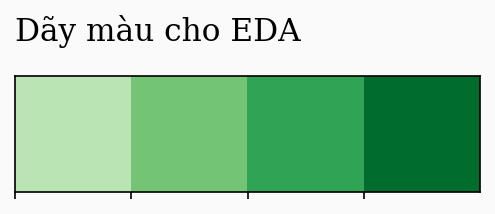

In [5]:
# Palette
palette = ["#bae4b3", "#74c476", "#31a354", "#006d2c"]
sns.palplot(palette)

plt.title("Dãy màu cho EDA",loc='left',fontsize=15,y=1.2)
plt.show()

## **📈 Target Variable Distribution - Churn (Phân bố biến mục tiêu - Churn)**


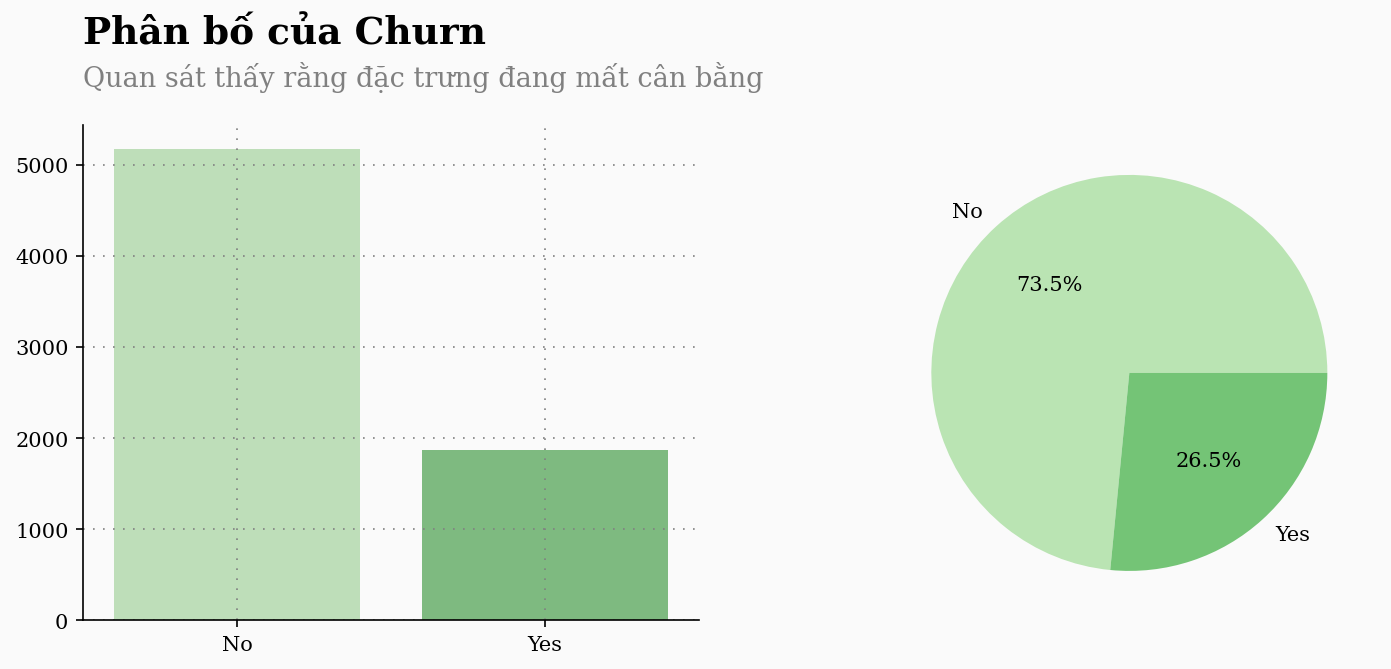

In [6]:
fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])

for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)


sns.countplot(ax=ax0, x=telco["Churn"], palette=palette)

Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()
ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Phân bố của Churn", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Quan sát thấy rằng đặc trưng đang mất cân bằng", color="gray",
fontsize=13, ha="left", va="top")


size = telco["Churn"].value_counts() / telco.shape[0] * 100 # Tính tỷ lệ trong churn

plt.pie(size, labels=size.index, colors=palette, autopct='%1.1f%%')

ax0.set_xlabel("")
ax0.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))

plt.show()

**Nhận xét**

Đặc trưng mục tiêu **Churn** có khả năng bị mất cân bằng
- Cột No cao hơn cột Yes
- Tỷ lệ No chiếm nhiều hơn cột Yes

Điều này là hiển nhiên trong dữ liệu thực tế bởi lẽ không phải dữ liệu lúc nào cũng hoàn hảo

## **👤 Personal Factors vs Churn (So sánh Churn và Không Churn theo các thống tin cá nhân)**




In [7]:
personals = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure']

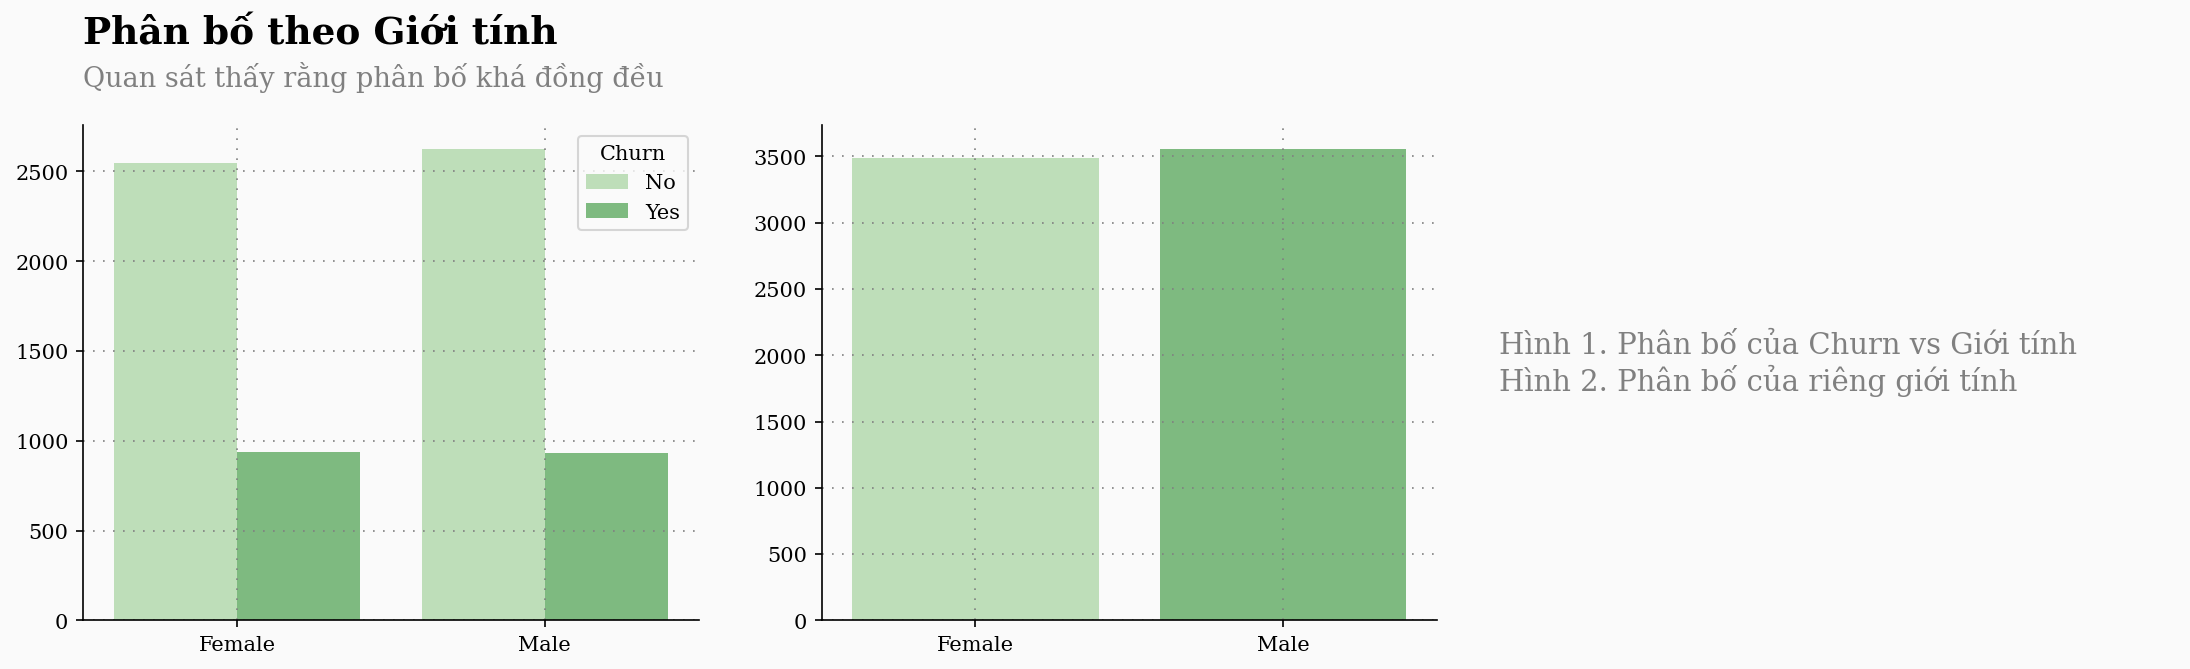

In [43]:
telco_personals = telco[personals]

fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.2, hspace=0.25)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])


for s in ["right", "top"]:
    ax0.spines[s].set_visible(False)
    ax1.spines[s].set_visible(False)



sns.countplot(ax=ax1, x=telco_personals['gender'], palette=palette)
sns.countplot(ax=ax0, x=telco_personals['gender'], hue=telco['Churn'], palette=palette)



Xstart, Xend = ax0.get_xlim()
Ystart, Yend = ax0.get_ylim()

ax0.set_ylim([0,Yend])
ax0.text(Xstart,Yend+(Yend*0.15), "Phân bố theo Giới tính", fontsize=18, ha="left", va="bottom", weight="bold")
ax0.text(Xstart,Yend+(Yend*0.13), "Quan sát thấy rằng phân bố khá đồng đều", color="gray",
fontsize=13, ha="left", va="top")

ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax0.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax0.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
ax1.grid(which='major', axis='x', zorder=0, color='gray', linestyle=':', dashes=(1,5))
ax1.grid(color='gray', linestyle=':', axis='y', zorder=0,  dashes=(1,5))


ax2.axis('off')  # Ẩn trục
ax2.text(-0.1, 0.4,
             "Hình 1. Phân bố của Churn vs Giới tính\n"
             "Hình 2. Phân bố của riêng giới tính\n",
             fontsize=14,  color="gray")

plt.show()

## **👨‍👩‍👧‍👦 Social vs Churn (So sánh Churn và Không Churn theo các thống tin xã hội)**


In [9]:
socicals = ['InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','','','','', ]

## **🤝 Relationships Factors vs Churn (So sánh Churn và Không Churn theo các thống tin liên lạc)**



In [10]:
relations = ['PhoneService', 'MultipleLines']

## **🔄 Contract Factors vs Churn (So sánh Churn và Không Churn theo các thống tin hợp đồng)**




In [11]:
cotracts = ['StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

## **🔍 Correlation Analysis (Phân tích quan hệ)**

In [12]:
telco.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## **✅ EDA Summary (Tóm tắt Khám phá dữ liệu)**